<a href="https://colab.research.google.com/github/oihika/AI-Enabled-Predictive-Energy-Management-for-Smart-Sustainable-Communities-A-Hydro-PV-BESS-Fram/blob/main/PV-hydro-wind-bess%20integration%20code%20with%20output.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



 HYDRO–PV–WIND–BESS ENERGY MANAGEMENT SYSTEM
 DUCK CURVE + GRID STABILITY SIMULATION
 Developed by Oihika Arpit

SYSTEM PERFORMANCE
------------------------------------------------------------------------------
Total Demand                 : 2625.00 MWh
Renewable Energy Supplied   : 1311.97 MWh
Renewable Energy Share      : 49.98%
Fossil Grid Support         : 1313.03 MWh
Renewable Curtailment       : 0.00 MWh
Final Battery SOC           : 20.00%
Carbon Emission             : 1076687.30 kg CO2e


 DUCK CURVE RELATIONSHIP

Core equation:
Net Load = Gross Demand - Solar Generation

Midday effect:
  Duck Curve depth                  : 60.00 MW
  Maximum midday renewable surplus  : 0.00 MW
  Midday BESS charging              : 0.00 MWh

Evening ramp:
  Solar-only evening ramp           : 15.25 MW
  Evening ramp after BESS           : 20.46 MW
  Duck Curve ramp reduction         : -5.21 MW
  Duck Curve mitigation             : -34.18%
  Evening BESS discharge             : 0.00 MWh

Inter

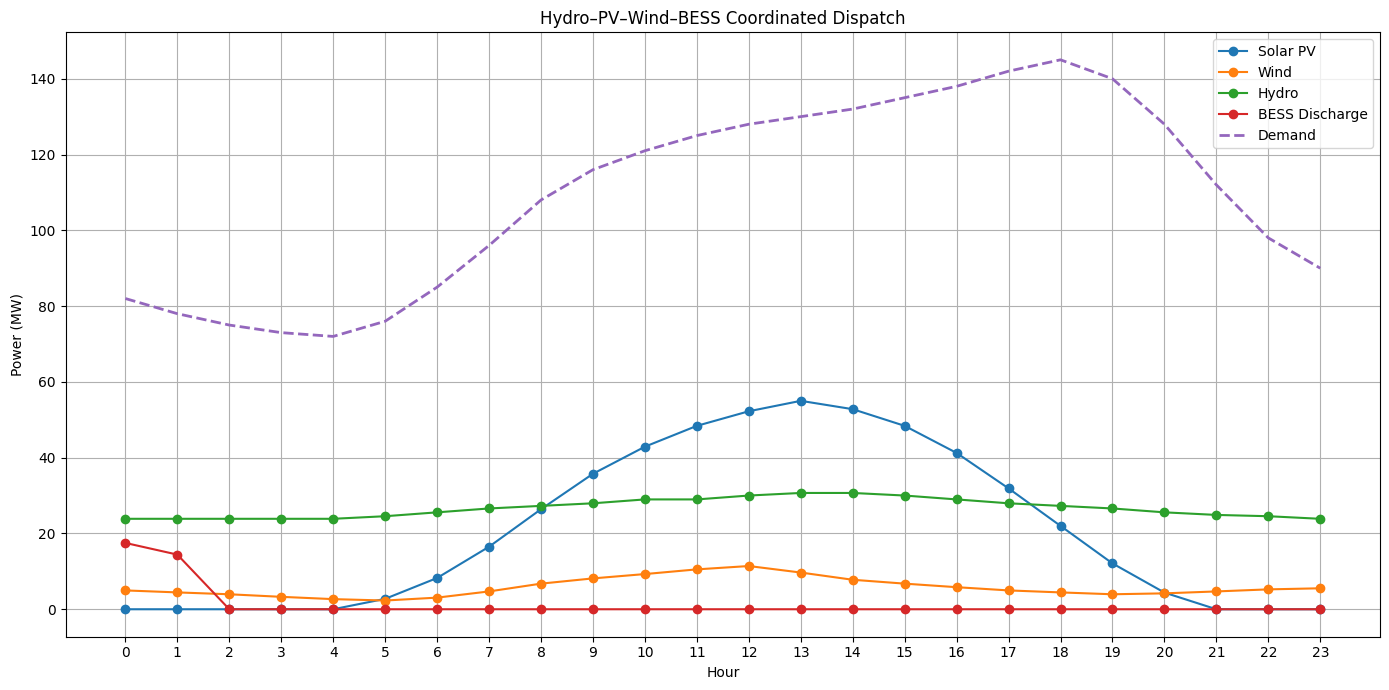

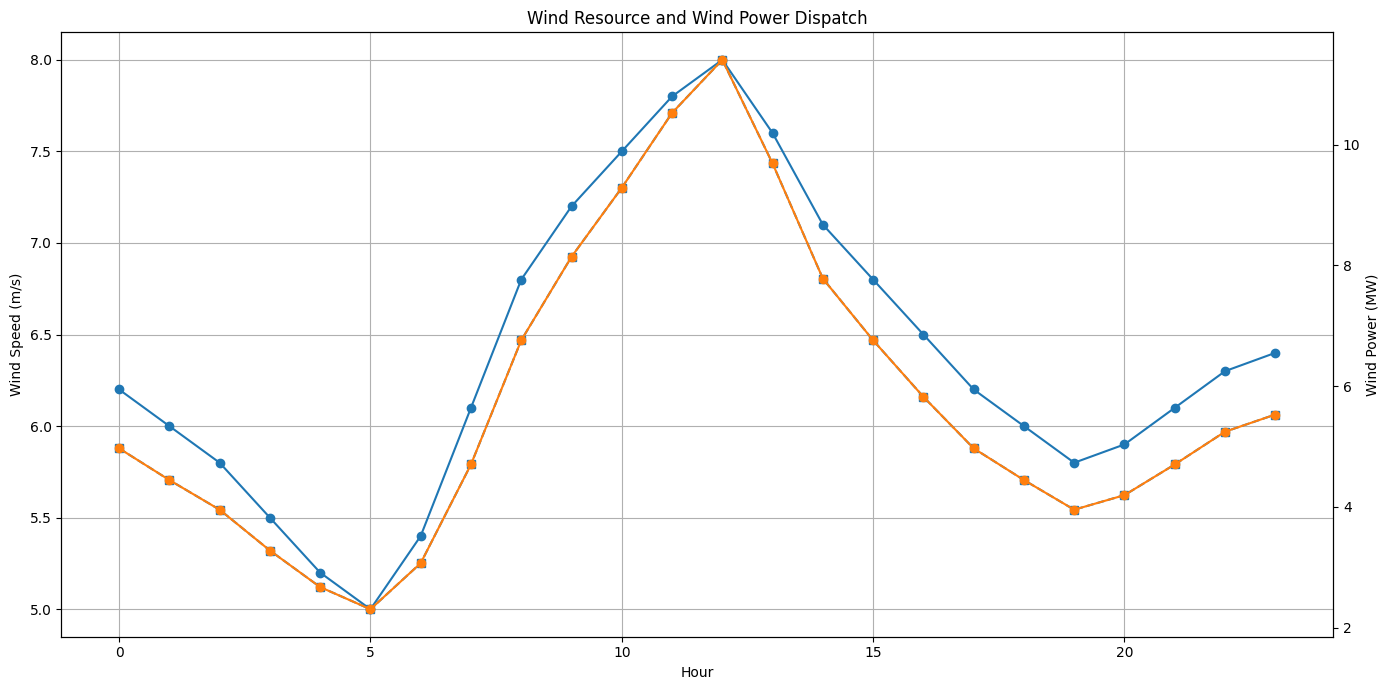

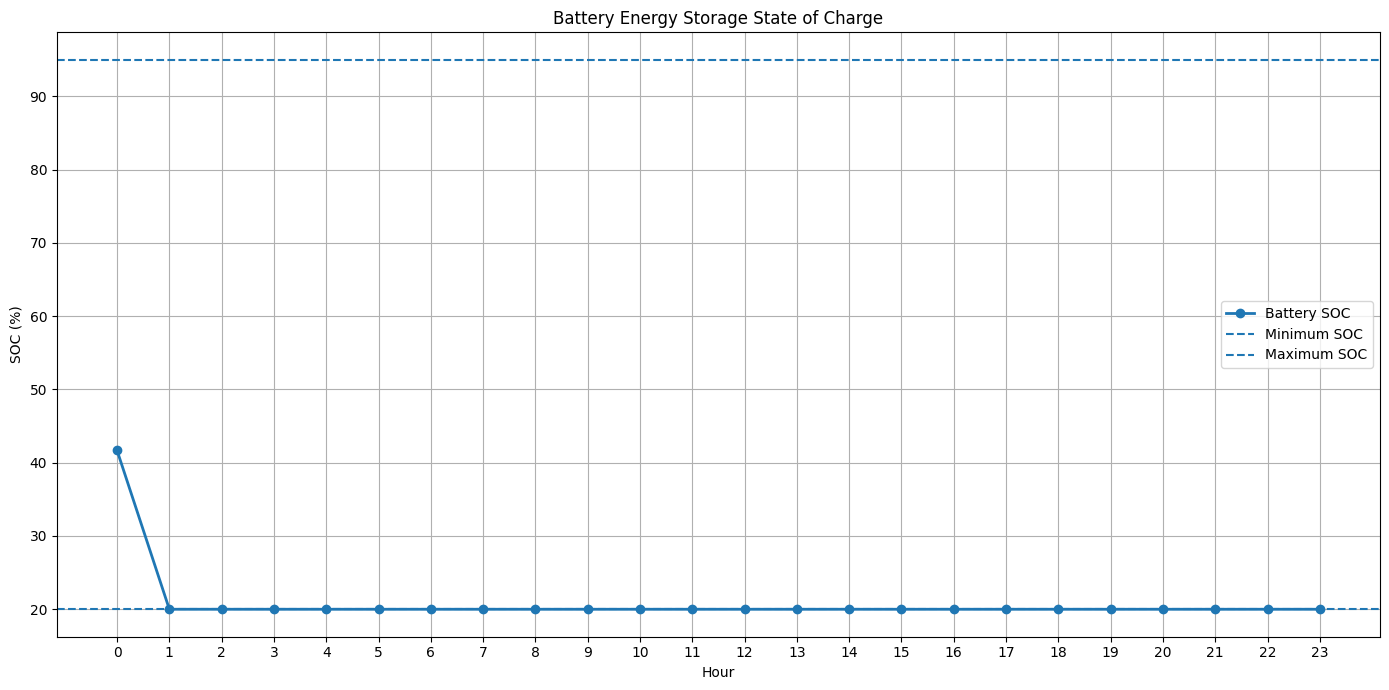

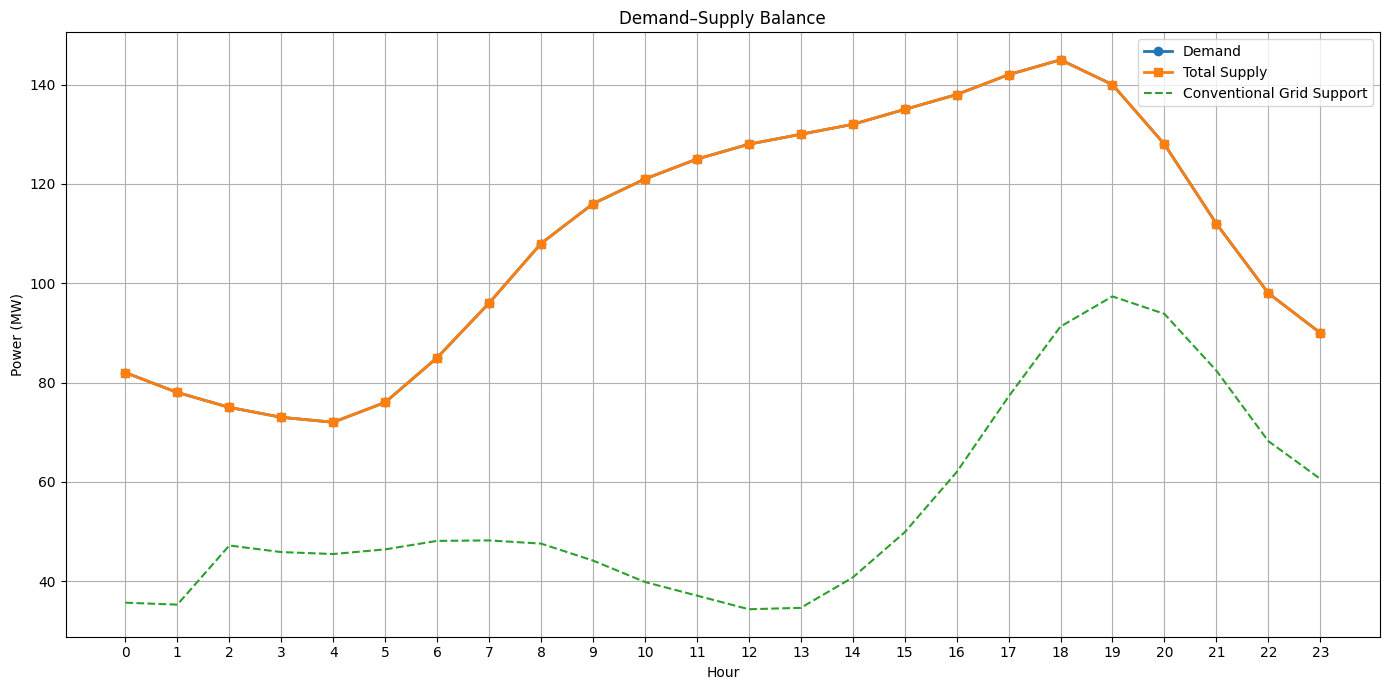

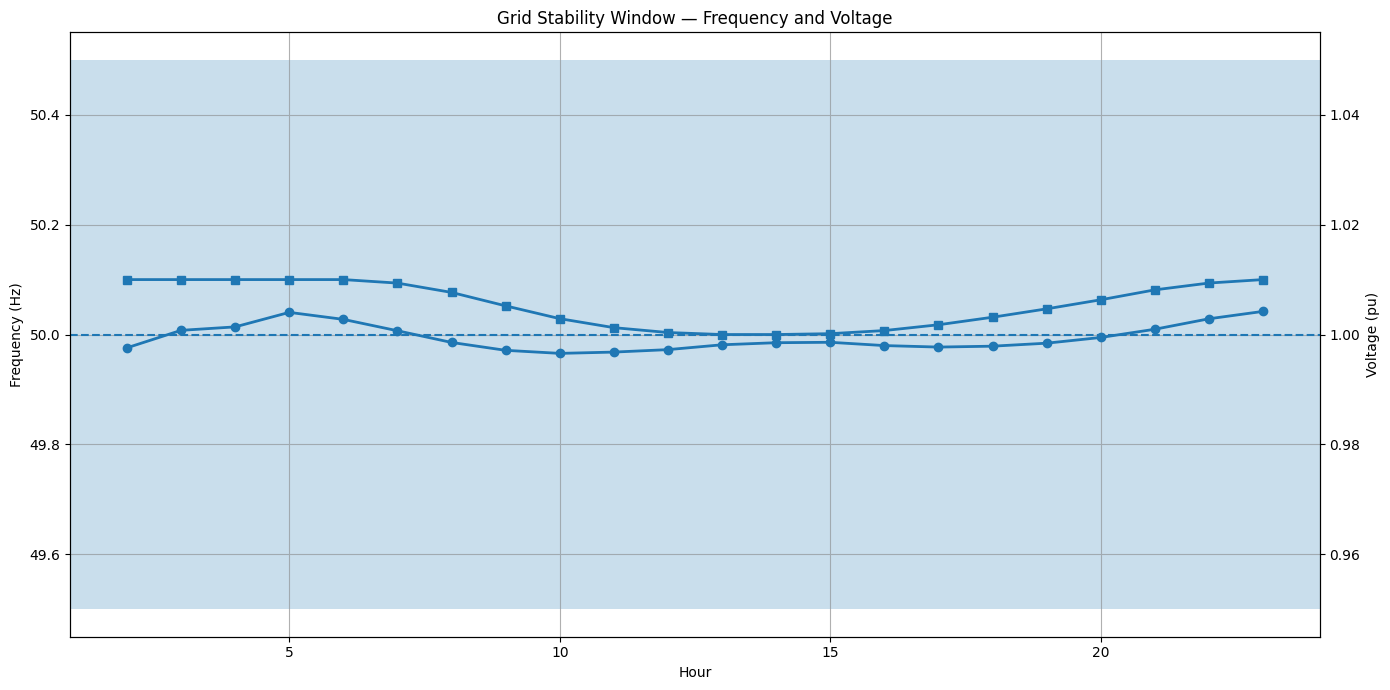

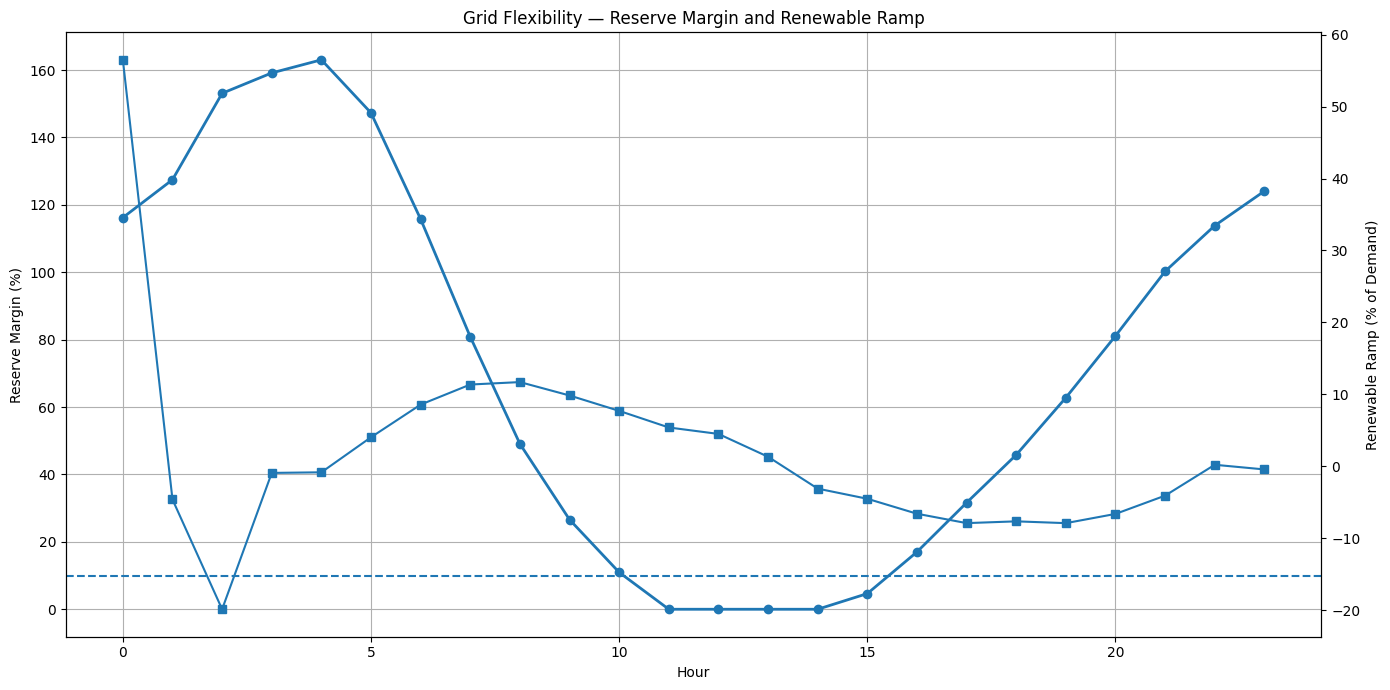

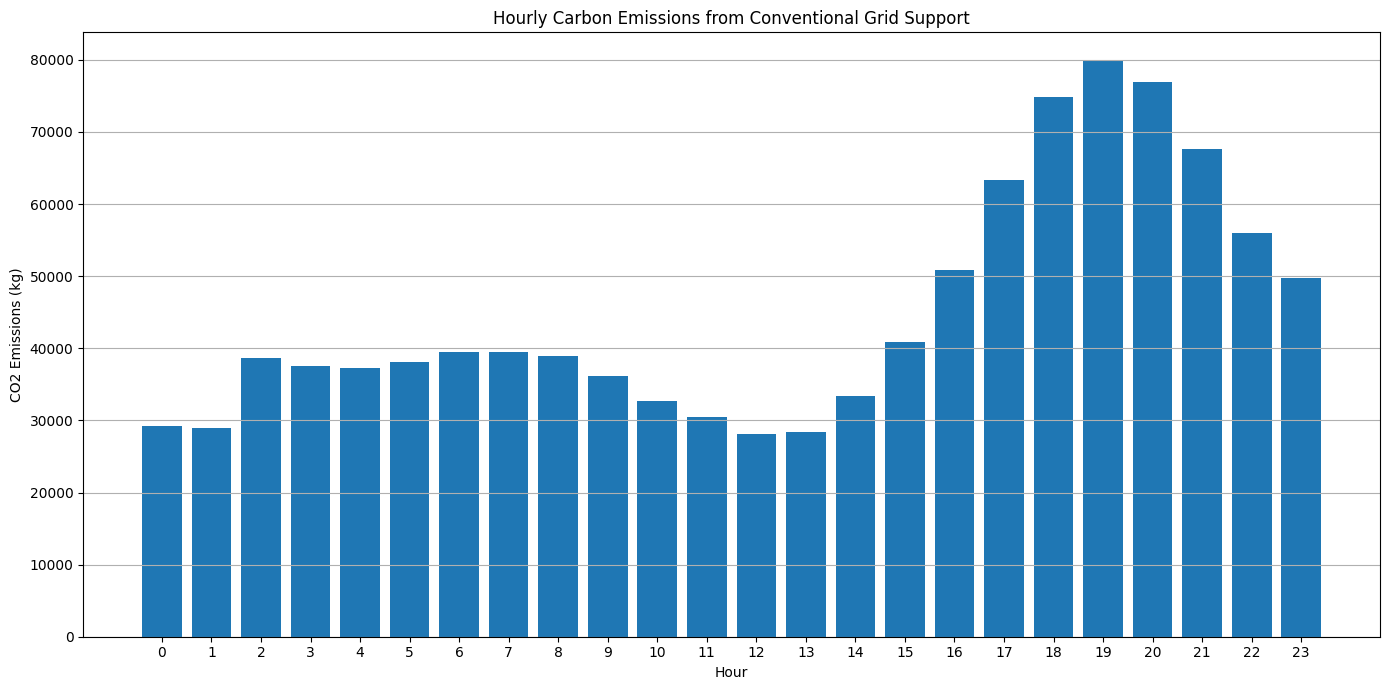

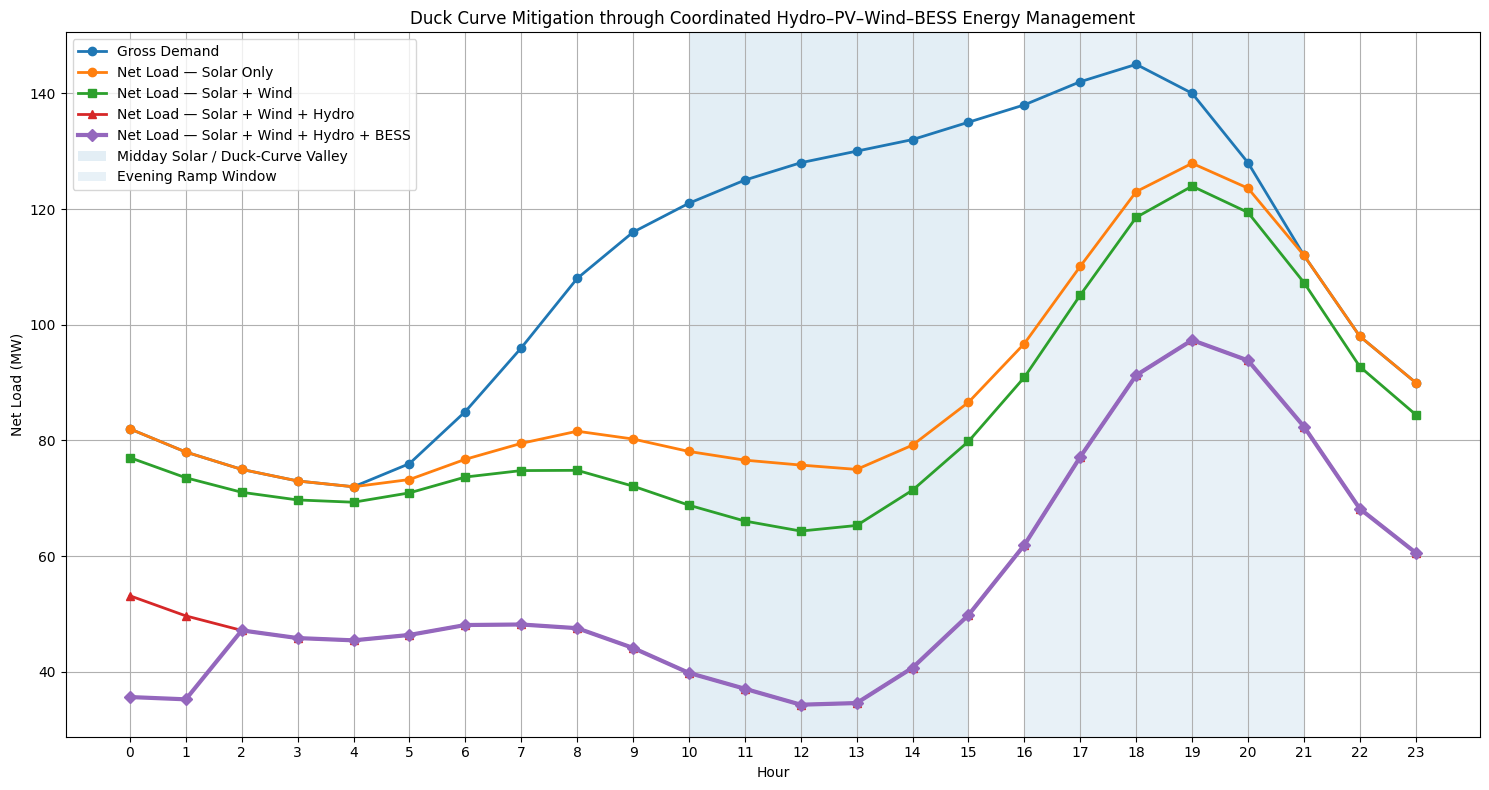

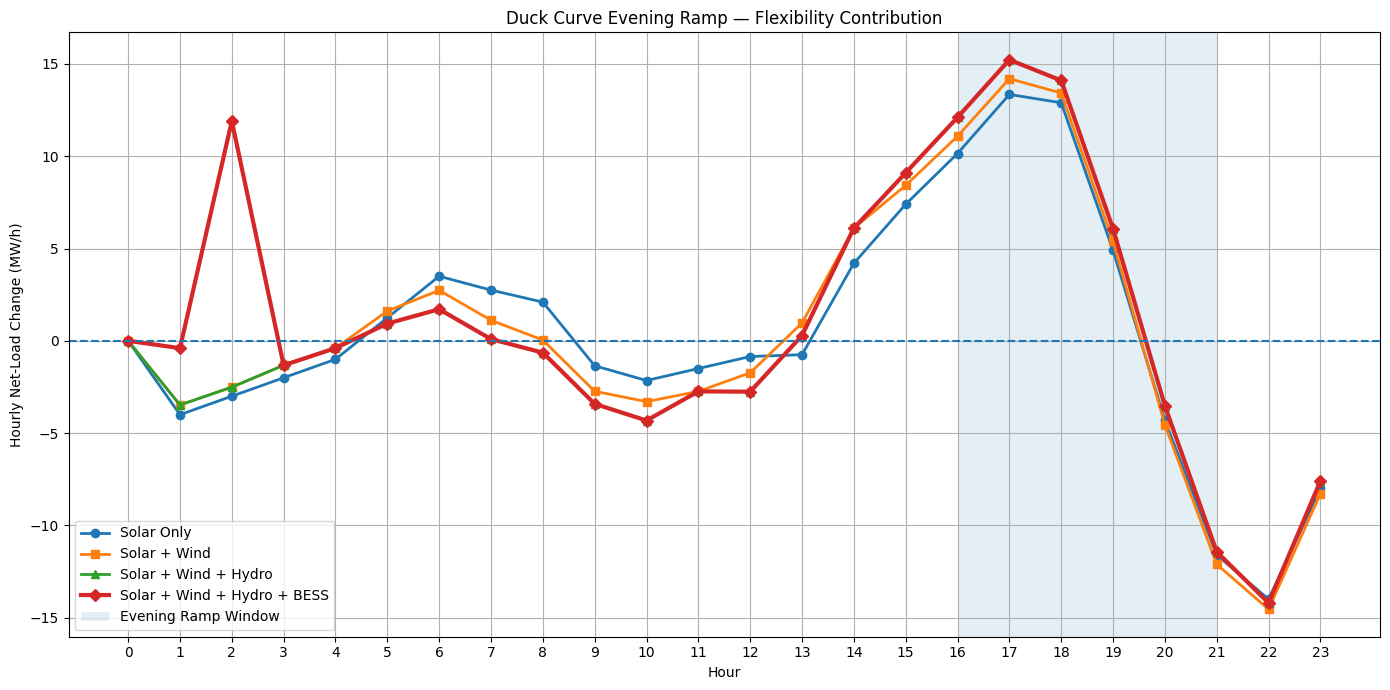

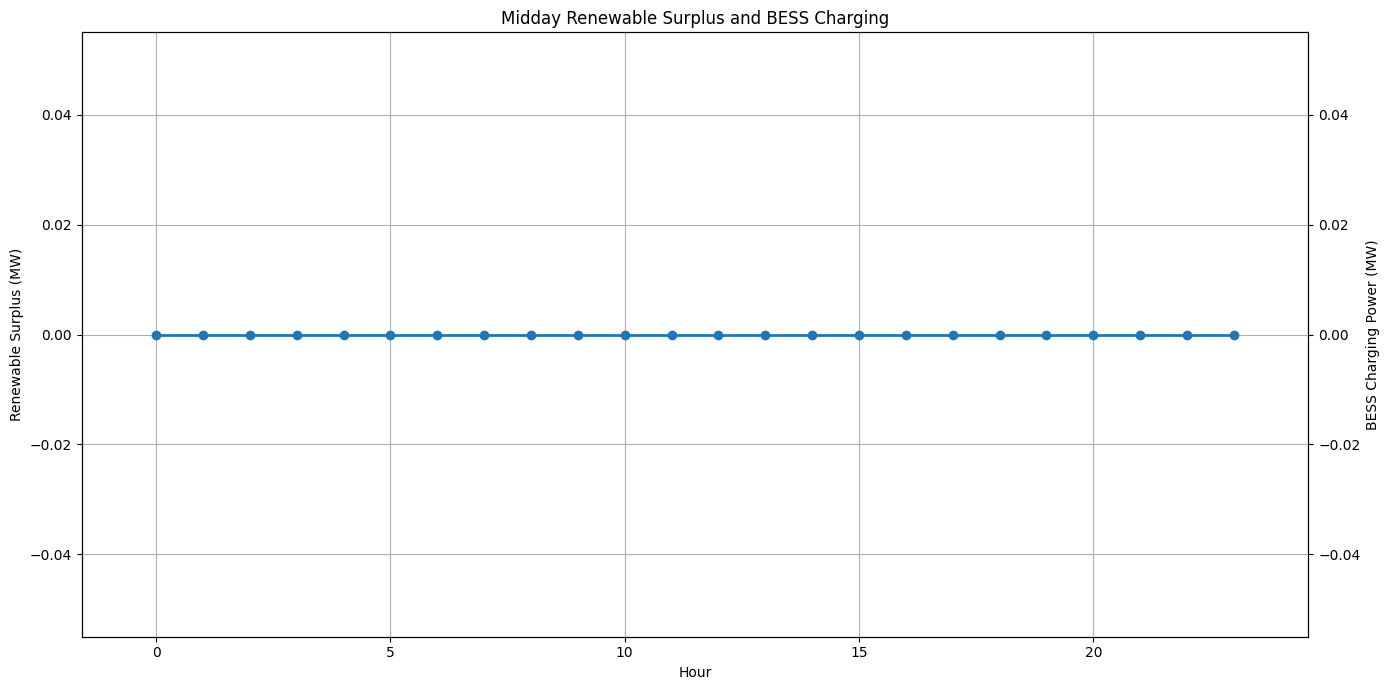

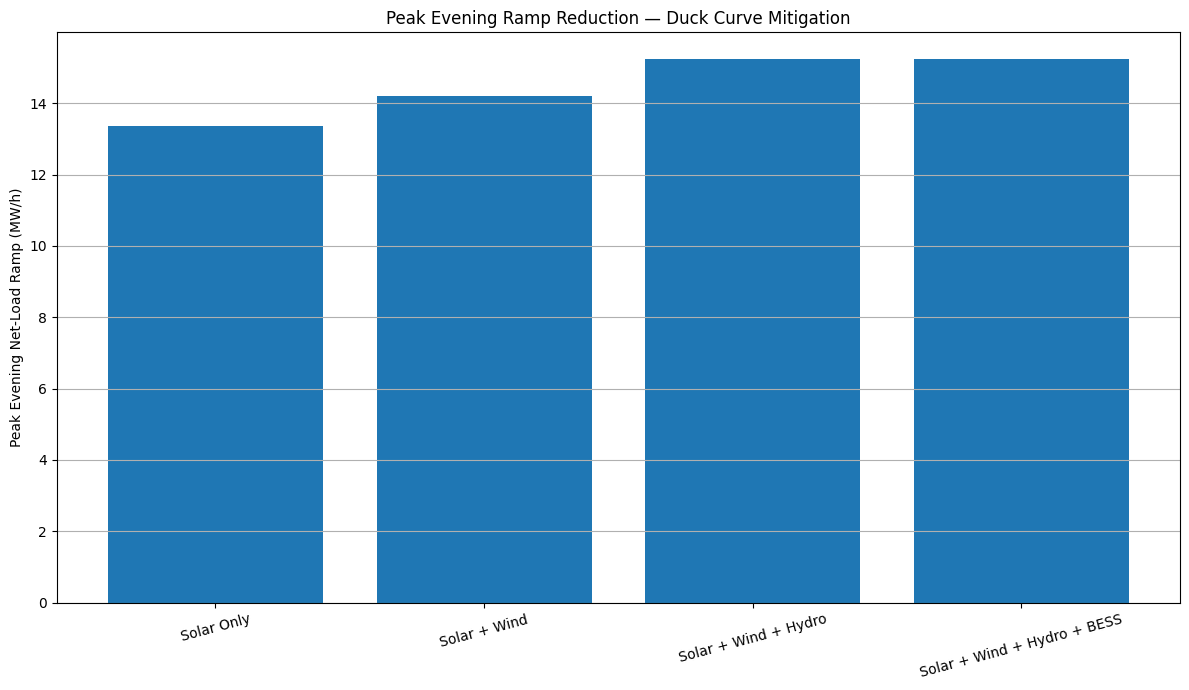



 SIMULATION COMPLETED SUCCESSFULLY

Results directory: hydro_pv_wind_bess_grid_stability_results
ZIP package: hydro_pv_wind_bess_duck_curve_grid_stability.zip

Generated outputs:
 - 01_four_source_dispatch.png
 - 02_wind_resource_dispatch.png
 - 03_battery_soc.png
 - 04_demand_supply_balance.png
 - 05_grid_stability_window.png
 - 06_reserve_and_renewable_ramp.png
 - 07_carbon_footprint.png
 - 08_duck_curve_mitigation.png
 - 09_duck_curve_ramp_comparison.png
 - 10_midday_surplus_bess_charging.png
 - 11_peak_evening_ramp_reduction.png
 - duck_curve_analysis.csv
 - hydro_pv_wind_bess_duck_curve_ems_results.csv
 - hydro_pv_wind_bess_duck_curve_report.txt
 - system_and_duck_curve_metrics.json
 - system_assumptions.json


Research interpretation:
High solar generation creates a midday net-load depression (Duck Curve).
Wind provides complementary renewable generation.
BESS absorbs/returns energy to reduce the evening ramp.
Hydro provides dispatchable balancing support.
The combined EMS is t

In [6]:
"""
HYDRO–PV–WIND–BESS ENERGY MANAGEMENT SYSTEM
Duck Curve Mitigation + Grid Stability Window

Developed by: Oihika Arpit
Reference context: Jabalpur hydro-energy system

Purpose
-------
Offline research / educational prototype for coordinated dispatch of:
    1. Solar PV
    2. Wind
    3. Hydropower
    4. Battery Energy Storage System (BESS)
    5. Conventional grid/fossil fallback

The prototype explicitly demonstrates the relationship between:
    Solar penetration
        ↓
    Midday net-load depression
        ↓
    Duck Curve
        ↓
    Evening solar ramp-down
        ↓
    BESS + Hydro + Wind flexibility
        ↓
    Reduced evening net-load ramp
        ↓
    Improved grid-stability indicators

IMPORTANT
---------
The frequency and voltage calculations are simplified research indicators.
They are NOT a substitute for:
    - SCADA/control-room control
    - AC load flow
    - transient stability analysis
    - RMS dynamic simulation
    - EMT simulation
    - validated governor/exciter models

All numerical capacities/profiles below are illustrative unless explicitly
matched to a validated plant dataset.
"""

import os
import json
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. SYSTEM PARAMETERS
# ============================================================

# Renewable generation capacities
SOLAR_CAPACITY_MW = 55.0
WIND_CAPACITY_MW = 40.0

# Reference hydro dispatch capability used in the original model
HYDRO_CAPACITY_MW = 34.10

# Battery
BATTERY_POWER_MW = 17.50
BATTERY_ENERGY_MWH = 70.00

INITIAL_SOC = 0.68
BATTERY_MIN_SOC = 0.20
BATTERY_MAX_SOC = 0.95

CHARGE_EFFICIENCY = 0.95
DISCHARGE_EFFICIENCY = 0.95

TIME_STEP_HOURS = 1.0


# ============================================================
# 2. GRID PARAMETERS
# ============================================================

NOMINAL_FREQUENCY_HZ = 50.0
NOMINAL_VOLTAGE_PU = 1.00

FREQUENCY_STABLE_MIN = 49.50
FREQUENCY_STABLE_MAX = 50.50

FREQUENCY_WARNING_MIN = 49.80
FREQUENCY_WARNING_MAX = 50.20

VOLTAGE_STABLE_MIN = 0.95
VOLTAGE_STABLE_MAX = 1.05

VOLTAGE_WARNING_MIN = 0.98
VOLTAGE_WARNING_MAX = 1.02

MIN_RESERVE_MARGIN_PERCENT = 10.0

# Three-hour rolling stability window
STABILITY_WINDOW_HOURS = 3


# ============================================================
# 3. DUCK CURVE WINDOWS
# ============================================================

# These windows are intentionally explicit so that the relationship
# can be seen directly in the output.
MIDDAY_START = 10
MIDDAY_END = 15

EVENING_START = 16
EVENING_END = 21


# ============================================================
# 4. OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = "hydro_pv_wind_bess_grid_stability_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# 5. 24-HOUR DEMAND PROFILE
# ============================================================

hours = np.arange(24)

demand_mw = np.array([
    82, 78, 75, 73, 72, 76,
    85, 96, 108, 116, 121, 125,
    128, 130, 132, 135, 138, 142,
    145, 140, 128, 112, 98, 90
], dtype=float)


# ============================================================
# 6. SOLAR PV PROFILE
# ============================================================

solar_profile = np.array([
    0.00, 0.00, 0.00, 0.00, 0.00, 0.05,
    0.15, 0.30, 0.48, 0.65, 0.78, 0.88,
    0.95, 1.00, 0.96, 0.88, 0.75, 0.58,
    0.40, 0.22, 0.08, 0.00, 0.00, 0.00
])

solar_available_mw = SOLAR_CAPACITY_MW * solar_profile


# ============================================================
# 7. WIND MODEL
# ============================================================

# Illustrative hourly wind-speed profile
wind_speed_ms = np.array([
    6.2, 6.0, 5.8, 5.5, 5.2, 5.0,
    5.4, 6.1, 6.8, 7.2, 7.5, 7.8,
    8.0, 7.6, 7.1, 6.8, 6.5, 6.2,
    6.0, 5.8, 5.9, 6.1, 6.3, 6.4
])


def wind_power_curve(speed_ms):
    """
    Simplified turbine power curve.

    Cut-in  = 3 m/s
    Rated   = 12 m/s
    Cut-out = 25 m/s
    """

    cut_in = 3.0
    rated_speed = 12.0
    cut_out = 25.0

    if speed_ms < cut_in or speed_ms >= cut_out:
        return 0.0

    if speed_ms < rated_speed:
        fraction = (
            speed_ms**3 - cut_in**3
        ) / (
            rated_speed**3 - cut_in**3
        )

        return WIND_CAPACITY_MW * np.clip(fraction, 0.0, 1.0)

    return WIND_CAPACITY_MW


wind_available_mw = np.array([
    wind_power_curve(v)
    for v in wind_speed_ms
])


# ============================================================
# 8. HYDRO AVAILABILITY PROFILE
# ============================================================

hydro_availability = np.array([
    0.70, 0.70, 0.70, 0.70, 0.70, 0.72,
    0.75, 0.78, 0.80, 0.82, 0.85, 0.85,
    0.88, 0.90, 0.90, 0.88, 0.85, 0.82,
    0.80, 0.78, 0.75, 0.73, 0.72, 0.70
])

hydro_available_mw = (
    HYDRO_CAPACITY_MW * hydro_availability
)


# ============================================================
# 9. BATTERY INITIAL STATE
# ============================================================

battery_energy_mwh = (
    BATTERY_ENERGY_MWH * INITIAL_SOC
)


# ============================================================
# 10. BATTERY FUNCTIONS
# ============================================================

def charge_battery(surplus_mw):
    """Charge BESS from renewable surplus."""

    global battery_energy_mwh

    available_capacity_mwh = (
        BATTERY_MAX_SOC * BATTERY_ENERGY_MWH
        - battery_energy_mwh
    )

    max_input_energy_mwh = (
        available_capacity_mwh
        / CHARGE_EFFICIENCY
    )

    charge_energy_mwh = min(
        surplus_mw * TIME_STEP_HOURS,
        BATTERY_POWER_MW * TIME_STEP_HOURS,
        max_input_energy_mwh
    )

    battery_energy_mwh += (
        charge_energy_mwh
        * CHARGE_EFFICIENCY
    )

    return charge_energy_mwh / TIME_STEP_HOURS


def discharge_battery(deficit_mw):
    """Discharge BESS to support load."""

    global battery_energy_mwh

    available_stored_energy_mwh = max(
        0.0,
        battery_energy_mwh
        - BATTERY_MIN_SOC * BATTERY_ENERGY_MWH
    )

    max_output_energy_mwh = (
        available_stored_energy_mwh
        * DISCHARGE_EFFICIENCY
    )

    discharge_energy_mwh = min(
        deficit_mw * TIME_STEP_HOURS,
        BATTERY_POWER_MW * TIME_STEP_HOURS,
        max_output_energy_mwh
    )

    battery_energy_mwh -= (
        discharge_energy_mwh
        / DISCHARGE_EFFICIENCY
    )

    return discharge_energy_mwh / TIME_STEP_HOURS


# ============================================================
# 11. GRID STABILITY FUNCTIONS
# ============================================================

def calculate_frequency(
    total_supply_mw,
    demand_value_mw,
    ramp_stress,
    reserve_ratio
):
    """
    Simplified frequency indicator.

    The value represents an illustrative relationship between:
        - supply-demand balance
        - renewable ramp stress
        - available reserve

    It is not a physical swing-equation solution.
    """

    power_mismatch_mw = (
        total_supply_mw - demand_value_mw
    )

    frequency_deviation_hz = (
        0.018 * power_mismatch_mw
        - 0.10 * ramp_stress
        + 0.05 * reserve_ratio
    )

    return (
        NOMINAL_FREQUENCY_HZ
        + frequency_deviation_hz
    )


def calculate_voltage(
    total_supply_mw,
    demand_value_mw,
    reserve_ratio
):
    """Simplified voltage stability indicator."""

    power_mismatch_mw = (
        total_supply_mw - demand_value_mw
    )

    voltage_pu = (
        NOMINAL_VOLTAGE_PU
        + 0.0015 * power_mismatch_mw
        + 0.01 * reserve_ratio
    )

    return np.clip(
        voltage_pu,
        0.90,
        1.10
    )


def get_instantaneous_status(
    frequency_hz,
    voltage_pu,
    reserve_margin_percent
):
    """Classify instantaneous grid condition."""

    frequency_stable = (
        FREQUENCY_STABLE_MIN
        <= frequency_hz
        <= FREQUENCY_STABLE_MAX
    )

    voltage_stable = (
        VOLTAGE_STABLE_MIN
        <= voltage_pu
        <= VOLTAGE_STABLE_MAX
    )

    reserve_stable = (
        reserve_margin_percent
        >= MIN_RESERVE_MARGIN_PERCENT
    )

    if (
        frequency_stable
        and voltage_stable
        and reserve_stable
    ):
        return "STABLE"

    frequency_warning = (
        FREQUENCY_WARNING_MIN
        <= frequency_hz
        <= FREQUENCY_WARNING_MAX
    )

    voltage_warning = (
        VOLTAGE_WARNING_MIN
        <= voltage_pu
        <= VOLTAGE_WARNING_MAX
    )

    if frequency_warning and voltage_warning:
        return "WARNING"

    return "STRESS"


# ============================================================
# 12. ENERGY MANAGEMENT SYSTEM DISPATCH
# ============================================================

results = []

previous_renewable_dispatch_mw = 0.0

for h in hours:

    demand = demand_mw[h]

    solar = solar_available_mw[h]
    wind = wind_available_mw[h]
    hydro_available = hydro_available_mw[h]

    # --------------------------------------------------------
    # 12.1 Variable renewable generation
    # --------------------------------------------------------

    variable_renewable_mw = (
        solar + wind
    )

    # Solar + wind first serve demand
    variable_renewable_to_load_mw = min(
        variable_renewable_mw,
        demand
    )

    solar_dispatch_mw = min(
        solar,
        variable_renewable_to_load_mw
    )

    wind_dispatch_mw = min(
        wind,
        max(
            0.0,
            variable_renewable_to_load_mw
            - solar_dispatch_mw
        )
    )

    remaining_demand_mw = max(
        0.0,
        demand
        - solar_dispatch_mw
        - wind_dispatch_mw
    )

    renewable_surplus_mw = max(
        0.0,
        variable_renewable_mw - demand
    )

    # --------------------------------------------------------
    # 12.2 BESS charging
    # --------------------------------------------------------

    battery_charge_mw = 0.0

    if renewable_surplus_mw > 0:

        battery_charge_mw = charge_battery(
            renewable_surplus_mw
        )

    # --------------------------------------------------------
    # 12.3 BESS discharge
    # --------------------------------------------------------

    battery_discharge_mw = 0.0

    if remaining_demand_mw > 0:

        battery_discharge_mw = discharge_battery(
            remaining_demand_mw
        )

        remaining_demand_mw -= (
            battery_discharge_mw
        )

    # --------------------------------------------------------
    # 12.4 Hydro balancing
    # --------------------------------------------------------

    hydro_dispatch_mw = min(
        hydro_available,
        remaining_demand_mw
    )

    remaining_demand_mw -= (
        hydro_dispatch_mw
    )

    # --------------------------------------------------------
    # 12.5 Conventional grid/fossil fallback
    # --------------------------------------------------------

    fossil_grid_support_mw = max(
        0.0,
        remaining_demand_mw
    )

    # --------------------------------------------------------
    # 12.6 Total system supply
    # --------------------------------------------------------

    total_supply_mw = (
        solar_dispatch_mw
        + wind_dispatch_mw
        + hydro_dispatch_mw
        + battery_discharge_mw
        + fossil_grid_support_mw
    )

    # --------------------------------------------------------
    # 12.7 Renewable supply
    # --------------------------------------------------------

    renewable_dispatch_mw = (
        solar_dispatch_mw
        + wind_dispatch_mw
        + hydro_dispatch_mw
        + battery_discharge_mw
    )

    # --------------------------------------------------------
    # 12.8 Renewable curtailment
    # --------------------------------------------------------

    renewable_curtailment_mw = max(
        0.0,
        (
            solar
            + wind
            + hydro_available
            - solar_dispatch_mw
            - wind_dispatch_mw
            - hydro_dispatch_mw
        )
    )

    # --------------------------------------------------------
    # 12.9 Reserve margin
    # --------------------------------------------------------

    total_dispatchable_capacity_mw = (
        HYDRO_CAPACITY_MW
        + BATTERY_POWER_MW
        + max(
            0.0,
            SOLAR_CAPACITY_MW - solar_dispatch_mw
        )
        + max(
            0.0,
            WIND_CAPACITY_MW - wind_dispatch_mw
        )
    )

    available_reserve_mw = max(
        0.0,
        total_dispatchable_capacity_mw
        - max(
            0.0,
            demand - fossil_grid_support_mw
        )
    )

    reserve_margin_percent = (
        available_reserve_mw
        / max(demand, 1.0)
    ) * 100.0

    # --------------------------------------------------------
    # 12.10 Renewable ramp
    # --------------------------------------------------------

    renewable_ramp_mw = (
        renewable_dispatch_mw
        - previous_renewable_dispatch_mw
    )

    renewable_ramp_percent = (
        renewable_ramp_mw
        / max(demand, 1.0)
    ) * 100.0

    ramp_stress = min(
        abs(renewable_ramp_percent) / 20.0,
        1.0
    )

    reserve_ratio = min(
        reserve_margin_percent / 100.0,
        1.0
    )

    # --------------------------------------------------------
    # 12.11 Frequency and voltage indicators
    # --------------------------------------------------------

    frequency_hz = calculate_frequency(
        total_supply_mw,
        demand,
        ramp_stress,
        reserve_ratio
    )

    voltage_pu = calculate_voltage(
        total_supply_mw,
        demand,
        reserve_ratio
    )

    instantaneous_status = get_instantaneous_status(
        frequency_hz,
        voltage_pu,
        reserve_margin_percent
    )

    # --------------------------------------------------------
    # 12.12 Battery state
    # --------------------------------------------------------

    battery_soc_percent = (
        battery_energy_mwh
        / BATTERY_ENERGY_MWH
    ) * 100.0

    # --------------------------------------------------------
    # 12.13 Wind indicators
    # --------------------------------------------------------

    wind_capacity_factor_percent = (
        wind_dispatch_mw
        / WIND_CAPACITY_MW
    ) * 100.0

    # --------------------------------------------------------
    # 12.14 Hydro indicators
    # --------------------------------------------------------

    hydro_loading_percent = (
        hydro_dispatch_mw
        / HYDRO_CAPACITY_MW
    ) * 100.0

    estimated_gate_opening_percent = (
        hydro_loading_percent * 0.70
    )

    base_water_discharge_m3s = 97.5

    water_discharge_m3s = (
        base_water_discharge_m3s
        * hydro_loading_percent
        / 100.0
    )

    # --------------------------------------------------------
    # 12.15 Carbon emissions
    # --------------------------------------------------------

    fossil_emission_factor_kg_per_kwh = 0.82

    carbon_emission_kg = (
        fossil_grid_support_mw
        * TIME_STEP_HOURS
        * 1000.0
        * fossil_emission_factor_kg_per_kwh
    )

    # --------------------------------------------------------
    # 12.16 Store results
    # --------------------------------------------------------

    results.append({

        "Hour": h,

        "Demand_MW": demand,

        "Solar_Available_MW": solar,
        "Solar_Dispatch_MW": solar_dispatch_mw,

        "Wind_Speed_mps": wind_speed_ms[h],
        "Wind_Available_MW": wind,
        "Wind_Dispatch_MW": wind_dispatch_mw,

        "Hydro_Available_MW": hydro_available,
        "Hydro_Dispatch_MW": hydro_dispatch_mw,

        "Battery_Charge_MW": battery_charge_mw,
        "Battery_Discharge_MW": battery_discharge_mw,

        "Battery_SOC_Percent":
            battery_soc_percent,

        "Battery_Energy_MWh":
            battery_energy_mwh,

        "Renewable_Dispatch_MW":
            renewable_dispatch_mw,

        "Renewable_Curtailment_MW":
            renewable_curtailment_mw,

        "Fossil_Grid_Support_MW":
            fossil_grid_support_mw,

        "Total_Supply_MW":
            total_supply_mw,

        "Reserve_MW":
            available_reserve_mw,

        "Reserve_Margin_Percent":
            reserve_margin_percent,

        "Renewable_Ramp_MW":
            renewable_ramp_mw,

        "Renewable_Ramp_Percent":
            renewable_ramp_percent,

        "Frequency_Hz":
            frequency_hz,

        "Frequency_Deviation_Hz":
            frequency_hz
            - NOMINAL_FREQUENCY_HZ,

        "Voltage_pu":
            voltage_pu,

        "Voltage_Deviation_pu":
            voltage_pu
            - NOMINAL_VOLTAGE_PU,

        "Instantaneous_Stability":
            instantaneous_status,

        "Wind_Capacity_Factor_Percent":
            wind_capacity_factor_percent,

        "Hydro_Loading_Percent":
            hydro_loading_percent,

        "Hydro_Gate_Opening_Percent":
            estimated_gate_opening_percent,

        "Water_Discharge_m3s":
            water_discharge_m3s,

        "Carbon_Emission_kg":
            carbon_emission_kg
    })

    previous_renewable_dispatch_mw = (
        renewable_dispatch_mw
    )


# ============================================================
# 13. DATAFRAME
# ============================================================

df = pd.DataFrame(results)


# ============================================================
# 14. DUCK CURVE ANALYSIS
# ============================================================

"""
Core relationship:

    Net Load = Gross Demand - Solar Generation

The classic duck-curve effect becomes visible when solar
generation creates a deep midday reduction in net load and
then declines rapidly toward the evening.

This prototype then compares:

    A. Solar-only net load
    B. Solar + Wind net load
    C. Solar + Wind + Hydro net load
    D. Solar + Wind + Hydro + BESS net load

The purpose is to show how coordinated flexible resources
reduce the evening net-load ramp.
"""

# ------------------------------------------------------------
# 14.1 Solar-only net load
# ------------------------------------------------------------

df["Net_Load_Solar_Only_MW"] = (
    df["Demand_MW"]
    - df["Solar_Dispatch_MW"]
)

# ------------------------------------------------------------
# 14.2 Solar + wind net load
# ------------------------------------------------------------

df["Net_Load_Solar_Wind_MW"] = (
    df["Demand_MW"]
    - df["Solar_Dispatch_MW"]
    - df["Wind_Dispatch_MW"]
)

# ------------------------------------------------------------
# 14.3 Solar + wind + hydro net load
# ------------------------------------------------------------

df["Net_Load_With_Hydro_MW"] = (
    df["Demand_MW"]
    - df["Solar_Dispatch_MW"]
    - df["Wind_Dispatch_MW"]
    - df["Hydro_Dispatch_MW"]
)

# ------------------------------------------------------------
# 14.4 Solar + wind + hydro + BESS net load
# ------------------------------------------------------------

df["Net_Load_With_BESS_MW"] = (
    df["Demand_MW"]
    - df["Solar_Dispatch_MW"]
    - df["Wind_Dispatch_MW"]
    - df["Hydro_Dispatch_MW"]
    - df["Battery_Discharge_MW"]
)


# ============================================================
# 15. DUCK CURVE RAMP CALCULATIONS
# ============================================================

df["Duck_Ramp_Solar_Only_MW"] = (
    df["Net_Load_Solar_Only_MW"]
    .diff()
    .fillna(0.0)
)

df["Duck_Ramp_With_Wind_MW"] = (
    df["Net_Load_Solar_Wind_MW"]
    .diff()
    .fillna(0.0)
)

df["Duck_Ramp_With_Hydro_MW"] = (
    df["Net_Load_With_Hydro_MW"]
    .diff()
    .fillna(0.0)
)

df["Duck_Ramp_With_BESS_MW"] = (
    df["Net_Load_With_BESS_MW"]
    .diff()
    .fillna(0.0)
)


# ============================================================
# 16. MIDDAY DUCK-CURVE INDICATORS
# ============================================================

midday_slice = df.loc[
    MIDDAY_START:MIDDAY_END
]

midday_net_load_min_mw = (
    midday_slice["Net_Load_Solar_Only_MW"].min()
)

midday_gross_demand_max_mw = (
    midday_slice["Demand_MW"].max()
)

duck_curve_depth_mw = (
    midday_gross_demand_max_mw
    - midday_net_load_min_mw
)

midday_renewable_surplus_mw = np.maximum(
    0.0,
    (
        midday_slice["Solar_Dispatch_MW"].values
        + midday_slice["Wind_Dispatch_MW"].values
        - midday_slice["Demand_MW"].values
    )
)

maximum_midday_surplus_mw = (
    np.max(midday_renewable_surplus_mw)
)

total_midday_surplus_mwh = (
    np.sum(midday_renewable_surplus_mw)
)


# ============================================================
# 17. EVENING DUCK-CURVE RAMP
# ============================================================

evening_start_net_load_solar = (
    df.loc[
        EVENING_START,
        "Net_Load_Solar_Only_MW"
    ]
)

evening_end_net_load_solar = (
    df.loc[
        EVENING_END,
        "Net_Load_Solar_Only_MW"
    ]
)

evening_start_net_load_bess = (
    df.loc[
        EVENING_START,
        "Net_Load_With_BESS_MW"
    ]
)

evening_end_net_load_bess = (
    df.loc[
        EVENING_END,
        "Net_Load_With_BESS_MW"
    ]
)

evening_ramp_solar_only_mw = (
    evening_end_net_load_solar
    - evening_start_net_load_solar
)

evening_ramp_with_bess_mw = (
    evening_end_net_load_bess
    - evening_start_net_load_bess
)

duck_curve_ramp_reduction_mw = (
    evening_ramp_solar_only_mw
    - evening_ramp_with_bess_mw
)

if abs(evening_ramp_solar_only_mw) > 1e-9:

    duck_curve_mitigation_percent = (
        duck_curve_ramp_reduction_mw
        / abs(evening_ramp_solar_only_mw)
    ) * 100.0

else:

    duck_curve_mitigation_percent = 0.0


# ============================================================
# 18. EVENING RAMP PEAK
# ============================================================

evening_slice = df.loc[
    EVENING_START:EVENING_END
]

peak_evening_ramp_solar_only_mw = (
    evening_slice["Duck_Ramp_Solar_Only_MW"].max()
)

peak_evening_ramp_with_wind_mw = (
    evening_slice["Duck_Ramp_With_Wind_MW"].max()
)

peak_evening_ramp_with_hydro_mw = (
    evening_slice["Duck_Ramp_With_Hydro_MW"].max()
)

peak_evening_ramp_with_bess_mw = (
    evening_slice["Duck_Ramp_With_BESS_MW"].max()
)


# ============================================================
# 19. BESS DUCK-CURVE SUPPORT
# ============================================================

total_bess_charging_midday_mwh = (
    df.loc[
        MIDDAY_START:MIDDAY_END,
        "Battery_Charge_MW"
    ].sum()
    * TIME_STEP_HOURS
)

total_bess_discharging_evening_mwh = (
    df.loc[
        EVENING_START:EVENING_END,
        "Battery_Discharge_MW"
    ].sum()
    * TIME_STEP_HOURS
)


# ============================================================
# 20. GRID STABILITY WINDOW
# ============================================================

df["Rolling_Frequency_Hz"] = (
    df["Frequency_Hz"]
    .rolling(
        STABILITY_WINDOW_HOURS
    )
    .mean()
)

df["Rolling_Voltage_pu"] = (
    df["Voltage_pu"]
    .rolling(
        STABILITY_WINDOW_HOURS
    )
    .mean()
)

df["Rolling_Reserve_Margin_Percent"] = (
    df["Reserve_Margin_Percent"]
    .rolling(
        STABILITY_WINDOW_HOURS
    )
    .mean()
)


def calculate_stability_window_status(row):

    if pd.isna(
        row["Rolling_Frequency_Hz"]
    ):
        return "INITIALIZING"

    frequency_ok = (
        FREQUENCY_STABLE_MIN
        <= row["Rolling_Frequency_Hz"]
        <= FREQUENCY_STABLE_MAX
    )

    voltage_ok = (
        VOLTAGE_STABLE_MIN
        <= row["Rolling_Voltage_pu"]
        <= VOLTAGE_STABLE_MAX
    )

    reserve_ok = (
        row["Rolling_Reserve_Margin_Percent"]
        >= MIN_RESERVE_MARGIN_PERCENT
    )

    if (
        frequency_ok
        and voltage_ok
        and reserve_ok
    ):
        return "STABLE WINDOW"

    if (
        row["Rolling_Reserve_Margin_Percent"]
        >= 5.0
    ):
        return "WATCH"

    return "UNSTABLE WINDOW"


df["Grid_Stability_Window"] = df.apply(
    calculate_stability_window_status,
    axis=1
)


# ============================================================
# 21. ENERGY AND CARBON METRICS
# ============================================================

total_demand_mwh = (
    df["Demand_MW"].sum()
    * TIME_STEP_HOURS
)

total_renewable_mwh = (
    df["Renewable_Dispatch_MW"].sum()
    * TIME_STEP_HOURS
)

total_fossil_mwh = (
    df["Fossil_Grid_Support_MW"].sum()
    * TIME_STEP_HOURS
)

total_curtailment_mwh = (
    df["Renewable_Curtailment_MW"].sum()
    * TIME_STEP_HOURS
)

renewable_share_percent = (
    total_renewable_mwh
    / max(total_demand_mwh, 1.0)
) * 100.0

average_wind_capacity_factor_percent = (
    df["Wind_Capacity_Factor_Percent"].mean()
)

minimum_reserve_margin_percent = (
    df["Reserve_Margin_Percent"].min()
)

average_frequency_hz = (
    df["Frequency_Hz"].mean()
)

minimum_frequency_hz = (
    df["Frequency_Hz"].min()
)

maximum_frequency_hz = (
    df["Frequency_Hz"].max()
)

average_voltage_pu = (
    df["Voltage_pu"].mean()
)

minimum_voltage_pu = (
    df["Voltage_pu"].min()
)

maximum_voltage_pu = (
    df["Voltage_pu"].max()
)

total_carbon_emission_kg = (
    df["Carbon_Emission_kg"].sum()
)


# ============================================================
# 22. STABILITY SUMMARY
# ============================================================

stable_hours = int(
    (
        df["Instantaneous_Stability"]
        == "STABLE"
    ).sum()
)

warning_hours = int(
    (
        df["Instantaneous_Stability"]
        == "WARNING"
    ).sum()
)

stress_hours = int(
    (
        df["Instantaneous_Stability"]
        == "STRESS"
    ).sum()
)

stable_window_hours = int(
    (
        df["Grid_Stability_Window"]
        == "STABLE WINDOW"
    ).sum()
)


# ============================================================
# 23. METRICS DICTIONARY
# ============================================================

metrics = {

    "Total_Demand_MWh":
        float(total_demand_mwh),

    "Renewable_Energy_Supplied_MWh":
        float(total_renewable_mwh),

    "Renewable_Energy_Share_Percent":
        float(renewable_share_percent),

    "Fossil_Grid_Support_MWh":
        float(total_fossil_mwh),

    "Renewable_Curtailment_MWh":
        float(total_curtailment_mwh),

    "Average_Wind_Capacity_Factor_Percent":
        float(average_wind_capacity_factor_percent),

    "Minimum_Reserve_Margin_Percent":
        float(minimum_reserve_margin_percent),

    "Average_Frequency_Hz":
        float(average_frequency_hz),

    "Minimum_Frequency_Hz":
        float(minimum_frequency_hz),

    "Maximum_Frequency_Hz":
        float(maximum_frequency_hz),

    "Average_Voltage_pu":
        float(average_voltage_pu),

    "Minimum_Voltage_pu":
        float(minimum_voltage_pu),

    "Maximum_Voltage_pu":
        float(maximum_voltage_pu),

    "Stable_Hours":
        stable_hours,

    "Warning_Hours":
        warning_hours,

    "Stress_Hours":
        stress_hours,

    "Stable_Window_Hours":
        stable_window_hours,

    "Final_Battery_SOC_Percent":
        float(df["Battery_SOC_Percent"].iloc[-1]),

    "Total_Carbon_Emission_kg":
        float(total_carbon_emission_kg),

    "Duck_Curve_Depth_MW":
        float(duck_curve_depth_mw),

    "Maximum_Midday_Renewable_Surplus_MW":
        float(maximum_midday_surplus_mw),

    "Total_Midday_Renewable_Surplus_MWh":
        float(total_midday_surplus_mwh),

    "Evening_Ramp_Solar_Only_MW":
        float(evening_ramp_solar_only_mw),

    "Evening_Ramp_With_BESS_MW":
        float(evening_ramp_with_bess_mw),

    "Duck_Curve_Ramp_Reduction_MW":
        float(duck_curve_ramp_reduction_mw),

    "Duck_Curve_Ramp_Mitigation_Percent":
        float(duck_curve_mitigation_percent),

    "Peak_Evening_Ramp_Solar_Only_MW":
        float(peak_evening_ramp_solar_only_mw),

    "Peak_Evening_Ramp_With_Wind_MW":
        float(peak_evening_ramp_with_wind_mw),

    "Peak_Evening_Ramp_With_Hydro_MW":
        float(peak_evening_ramp_with_hydro_mw),

    "Peak_Evening_Ramp_With_BESS_MW":
        float(peak_evening_ramp_with_bess_mw),

    "Midday_BESS_Charging_MWh":
        float(total_bess_charging_midday_mwh),

    "Evening_BESS_Discharging_MWh":
        float(total_bess_discharging_evening_mwh)
}


# ============================================================
# 24. ASSUMPTIONS
# ============================================================

assumptions = {

    "Developer":
        "Oihika Arpit",

    "System":
        "Hydro-PV-Wind-BESS Energy Management System",

    "Simulation_Type":
        "Offline research / educational prototype",

    "Solar_Capacity_MW":
        SOLAR_CAPACITY_MW,

    "Wind_Capacity_MW":
        WIND_CAPACITY_MW,

    "Hydro_Capacity_MW":
        HYDRO_CAPACITY_MW,

    "Battery_Power_MW":
        BATTERY_POWER_MW,

    "Battery_Energy_MWh":
        BATTERY_ENERGY_MWH,

    "Initial_SOC":
        INITIAL_SOC,

    "Minimum_SOC":
        BATTERY_MIN_SOC,

    "Maximum_SOC":
        BATTERY_MAX_SOC,

    "Nominal_Frequency_Hz":
        NOMINAL_FREQUENCY_HZ,

    "Nominal_Voltage_pu":
        NOMINAL_VOLTAGE_PU,

    "Stability_Window_Hours":
        STABILITY_WINDOW_HOURS,

    "Midday_Duck_Curve_Window":
        f"{MIDDAY_START}:00-{MIDDAY_END}:00",

    "Evening_Ramp_Window":
        f"{EVENING_START}:00-{EVENING_END}:00",

    "Frequency_Model":
        "Simplified stability indicator",

    "Voltage_Model":
        "Simplified stability indicator",

    "Duck_Curve_Relation":
        "Net Load = Demand - Solar; flexible Hydro, Wind and BESS reduce evening ramp stress."
}


# ============================================================
# 25. PRINT MAIN EMS DASHBOARD
# ============================================================

print("\n")
print("=" * 78)
print(" HYDRO–PV–WIND–BESS ENERGY MANAGEMENT SYSTEM")
print(" DUCK CURVE + GRID STABILITY SIMULATION")
print(" Developed by Oihika Arpit")
print("=" * 78)

print("\nSYSTEM PERFORMANCE")
print("-" * 78)

print(
    f"Total Demand                 : "
    f"{total_demand_mwh:.2f} MWh"
)

print(
    f"Renewable Energy Supplied   : "
    f"{total_renewable_mwh:.2f} MWh"
)

print(
    f"Renewable Energy Share      : "
    f"{renewable_share_percent:.2f}%"
)

print(
    f"Fossil Grid Support         : "
    f"{total_fossil_mwh:.2f} MWh"
)

print(
    f"Renewable Curtailment       : "
    f"{total_curtailment_mwh:.2f} MWh"
)

print(
    f"Final Battery SOC           : "
    f"{df['Battery_SOC_Percent'].iloc[-1]:.2f}%"
)

print(
    f"Carbon Emission             : "
    f"{total_carbon_emission_kg:.2f} kg CO2e"
)


# ============================================================
# 26. DUCK CURVE DASHBOARD
# ============================================================

print("\n")
print("=" * 78)
print(" DUCK CURVE RELATIONSHIP")
print("=" * 78)

print(
    "\nCore equation:"
)

print(
    "Net Load = Gross Demand - Solar Generation"
)

print(
    "\nMidday effect:"
)

print(
    f"  Duck Curve depth                  : "
    f"{duck_curve_depth_mw:.2f} MW"
)

print(
    f"  Maximum midday renewable surplus  : "
    f"{maximum_midday_surplus_mw:.2f} MW"
)

print(
    f"  Midday BESS charging              : "
    f"{total_bess_charging_midday_mwh:.2f} MWh"
)

print(
    "\nEvening ramp:"
)

print(
    f"  Solar-only evening ramp           : "
    f"{evening_ramp_solar_only_mw:.2f} MW"
)

print(
    f"  Evening ramp after BESS           : "
    f"{evening_ramp_with_bess_mw:.2f} MW"
)

print(
    f"  Duck Curve ramp reduction         : "
    f"{duck_curve_ramp_reduction_mw:.2f} MW"
)

print(
    f"  Duck Curve mitigation             : "
    f"{duck_curve_mitigation_percent:.2f}%"
)

print(
    f"  Evening BESS discharge             : "
    f"{total_bess_discharging_evening_mwh:.2f} MWh"
)

print(
    "\nInterpretation:"
)

print(
    "  1. Solar generation lowers midday net load."
)

print(
    "  2. The resulting midday depression forms the Duck Curve."
)

print(
    "  3. Solar output declines rapidly toward evening."
)

print(
    "  4. Wind provides complementary renewable generation."
)

print(
    "  5. BESS absorbs available midday renewable energy and "
    "supports the evening ramp."
)

print(
    "  6. Hydro provides dispatchable balancing capability."
)

print(
    "  7. Coordinated resources reduce the net-load ramp "
    "created by high solar penetration."
)


# ============================================================
# 27. GRID STABILITY DASHBOARD
# ============================================================

print("\n")
print("=" * 78)
print(" GRID STABILITY WINDOW")
print("=" * 78)

print(
    f"\nAverage Frequency : "
    f"{average_frequency_hz:.3f} Hz"
)

print(
    f"Frequency Range   : "
    f"{minimum_frequency_hz:.3f} - "
    f"{maximum_frequency_hz:.3f} Hz"
)

print(
    f"Average Voltage   : "
    f"{average_voltage_pu:.4f} pu"
)

print(
    f"Voltage Range     : "
    f"{minimum_voltage_pu:.4f} - "
    f"{maximum_voltage_pu:.4f} pu"
)

print(
    f"Minimum Reserve   : "
    f"{minimum_reserve_margin_percent:.2f}%"
)

print(
    f"Stable Hours      : "
    f"{stable_hours}"
)

print(
    f"Warning Hours     : "
    f"{warning_hours}"
)

print(
    f"Stress Hours      : "
    f"{stress_hours}"
)

print(
    f"Stable Window Hrs : "
    f"{stable_window_hours}"
)


# ============================================================
# 28. EXPORT CSV
# ============================================================

csv_path = os.path.join(
    OUTPUT_DIR,
    "hydro_pv_wind_bess_duck_curve_ems_results.csv"
)

df.to_csv(
    csv_path,
    index=False
)


# ============================================================
# 29. EXPORT METRICS
# ============================================================

metrics_path = os.path.join(
    OUTPUT_DIR,
    "system_and_duck_curve_metrics.json"
)

with open(
    metrics_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )


# ============================================================
# 30. EXPORT ASSUMPTIONS
# ============================================================

assumptions_path = os.path.join(
    OUTPUT_DIR,
    "system_assumptions.json"
)

with open(
    assumptions_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        assumptions,
        f,
        indent=4
    )


# ============================================================
# 31. PLOT — FOUR-SOURCE DISPATCH
# ============================================================

plt.figure(figsize=(14, 7))

plt.plot(
    hours,
    df["Solar_Dispatch_MW"],
    marker="o",
    label="Solar PV"
)

plt.plot(
    hours,
    df["Wind_Dispatch_MW"],
    marker="o",
    label="Wind"
)

plt.plot(
    hours,
    df["Hydro_Dispatch_MW"],
    marker="o",
    label="Hydro"
)

plt.plot(
    hours,
    df["Battery_Discharge_MW"],
    marker="o",
    label="BESS Discharge"
)

plt.plot(
    hours,
    df["Demand_MW"],
    linestyle="--",
    linewidth=2,
    label="Demand"
)

plt.xlabel("Hour")
plt.ylabel("Power (MW)")
plt.title(
    "Hydro–PV–Wind–BESS Coordinated Dispatch"
)

plt.xticks(hours)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "01_four_source_dispatch.png"
    ),
    dpi=300
)

plt.show()


# ============================================================
# 32. PLOT — WIND ENERGY
# ============================================================

fig, ax1 = plt.subplots(
    figsize=(14, 7)
)

ax1.plot(
    hours,
    wind_speed_ms,
    marker="o",
    label="Wind Speed"
)

ax1.set_xlabel("Hour")
ax1.set_ylabel("Wind Speed (m/s)")
ax1.grid(True)

ax2 = ax1.twinx()

ax2.plot(
    hours,
    df["Wind_Available_MW"],
    linestyle="--",
    marker="s",
    label="Available Wind"
)

ax2.plot(
    hours,
    df["Wind_Dispatch_MW"],
    marker="o",
    label="Wind Dispatch"
)

ax2.set_ylabel("Wind Power (MW)")

plt.title(
    "Wind Resource and Wind Power Dispatch"
)

fig.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "02_wind_resource_dispatch.png"
    ),
    dpi=300
)

plt.show()


# ============================================================
# 33. PLOT — BATTERY SOC
# ============================================================

plt.figure(figsize=(14, 7))

plt.plot(
    hours,
    df["Battery_SOC_Percent"],
    marker="o",
    linewidth=2,
    label="Battery SOC"
)

plt.axhline(
    BATTERY_MIN_SOC * 100,
    linestyle="--",
    label="Minimum SOC"
)

plt.axhline(
    BATTERY_MAX_SOC * 100,
    linestyle="--",
    label="Maximum SOC"
)

plt.xlabel("Hour")
plt.ylabel("SOC (%)")
plt.title(
    "Battery Energy Storage State of Charge"
)

plt.xticks(hours)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "03_battery_soc.png"
    ),
    dpi=300
)

plt.show()


# ============================================================
# 34. PLOT — DEMAND VS SUPPLY
# ============================================================

plt.figure(figsize=(14, 7))

plt.plot(
    hours,
    df["Demand_MW"],
    marker="o",
    linewidth=2,
    label="Demand"
)

plt.plot(
    hours,
    df["Total_Supply_MW"],
    marker="s",
    linewidth=2,
    label="Total Supply"
)

plt.plot(
    hours,
    df["Fossil_Grid_Support_MW"],
    linestyle="--",
    label="Conventional Grid Support"
)

plt.xlabel("Hour")
plt.ylabel("Power (MW)")
plt.title(
    "Demand–Supply Balance"
)

plt.xticks(hours)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "04_demand_supply_balance.png"
    ),
    dpi=300
)

plt.show()


# ============================================================
# 35. PLOT — GRID STABILITY WINDOW
# ============================================================

fig, ax1 = plt.subplots(
    figsize=(14, 7)
)

ax1.plot(
    hours,
    df["Rolling_Frequency_Hz"],
    marker="o",
    linewidth=2,
    label="3-Hour Frequency"
)

ax1.axhspan(
    FREQUENCY_STABLE_MIN,
    FREQUENCY_STABLE_MAX,
    alpha=0.15,
    label="Frequency Stable Band"
)

ax1.axhline(
    NOMINAL_FREQUENCY_HZ,
    linestyle="--",
    label="50 Hz Nominal"
)

ax1.set_xlabel("Hour")
ax1.set_ylabel("Frequency (Hz)")
ax1.grid(True)

ax2 = ax1.twinx()

ax2.plot(
    hours,
    df["Rolling_Voltage_pu"],
    marker="s",
    linewidth=2,
    label="3-Hour Voltage"
)

ax2.axhspan(
    VOLTAGE_STABLE_MIN,
    VOLTAGE_STABLE_MAX,
    alpha=0.10,
    label="Voltage Stable Band"
)

ax2.set_ylabel("Voltage (pu)")

plt.title(
    "Grid Stability Window — Frequency and Voltage"
)

fig.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "05_grid_stability_window.png"
    ),
    dpi=300
)

plt.show()


# ============================================================
# 36. PLOT — RESERVE AND RENEWABLE RAMP
# ============================================================

fig, ax1 = plt.subplots(
    figsize=(14, 7)
)

ax1.plot(
    hours,
    df["Reserve_Margin_Percent"],
    marker="o",
    linewidth=2,
    label="Reserve Margin"
)

ax1.axhline(
    MIN_RESERVE_MARGIN_PERCENT,
    linestyle="--",
    label="Minimum Reserve"
)

ax1.set_xlabel("Hour")
ax1.set_ylabel("Reserve Margin (%)")
ax1.grid(True)

ax2 = ax1.twinx()

ax2.plot(
    hours,
    df["Renewable_Ramp_Percent"],
    marker="s",
    label="Renewable Ramp"
)

ax2.set_ylabel(
    "Renewable Ramp (% of Demand)"
)

plt.title(
    "Grid Flexibility — Reserve Margin and Renewable Ramp"
)

fig.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "06_reserve_and_renewable_ramp.png"
    ),
    dpi=300
)

plt.show()


# ============================================================
# 37. PLOT — CARBON FOOTPRINT
# ============================================================

plt.figure(figsize=(14, 7))

plt.bar(
    hours,
    df["Carbon_Emission_kg"]
)

plt.xlabel("Hour")
plt.ylabel("CO2 Emissions (kg)")
plt.title(
    "Hourly Carbon Emissions from Conventional Grid Support"
)

plt.xticks(hours)
plt.grid(
    axis="y"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "07_carbon_footprint.png"
    ),
    dpi=300
)

plt.show()


# ============================================================
# 38. PLOT — DUCK CURVE RELATION
# ============================================================

plt.figure(figsize=(15, 8))

plt.plot(
    hours,
    df["Demand_MW"],
    marker="o",
    linewidth=2,
    label="Gross Demand"
)

plt.plot(
    hours,
    df["Net_Load_Solar_Only_MW"],
    marker="o",
    linewidth=2,
    label="Net Load — Solar Only"
)

plt.plot(
    hours,
    df["Net_Load_Solar_Wind_MW"],
    marker="s",
    linewidth=2,
    label="Net Load — Solar + Wind"
)

plt.plot(
    hours,
    df["Net_Load_With_Hydro_MW"],
    marker="^",
    linewidth=2,
    label="Net Load — Solar + Wind + Hydro"
)

plt.plot(
    hours,
    df["Net_Load_With_BESS_MW"],
    marker="D",
    linewidth=3,
    label="Net Load — Solar + Wind + Hydro + BESS"
)

# Midday Duck Curve zone
plt.axvspan(
    MIDDAY_START,
    MIDDAY_END,
    alpha=0.12,
    label="Midday Solar / Duck-Curve Valley"
)

# Evening ramp zone
plt.axvspan(
    EVENING_START,
    EVENING_END,
    alpha=0.10,
    label="Evening Ramp Window"
)

plt.xlabel("Hour")
plt.ylabel("Net Load (MW)")

plt.title(
    "Duck Curve Mitigation through Coordinated "
    "Hydro–PV–Wind–BESS Energy Management"
)

plt.xticks(hours)
plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "08_duck_curve_mitigation.png"
    ),
    dpi=300
)

plt.show()


# ============================================================
# 39. PLOT — DUCK CURVE EVENING RAMP COMPARISON
# ============================================================

plt.figure(figsize=(14, 7))

plt.plot(
    hours,
    df["Duck_Ramp_Solar_Only_MW"],
    marker="o",
    linewidth=2,
    label="Solar Only"
)

plt.plot(
    hours,
    df["Duck_Ramp_With_Wind_MW"],
    marker="s",
    linewidth=2,
    label="Solar + Wind"
)

plt.plot(
    hours,
    df["Duck_Ramp_With_Hydro_MW"],
    marker="^",
    linewidth=2,
    label="Solar + Wind + Hydro"
)

plt.plot(
    hours,
    df["Duck_Ramp_With_BESS_MW"],
    marker="D",
    linewidth=3,
    label="Solar + Wind + Hydro + BESS"
)

plt.axvspan(
    EVENING_START,
    EVENING_END,
    alpha=0.12,
    label="Evening Ramp Window"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Hour")
plt.ylabel("Hourly Net-Load Change (MW/h)")

plt.title(
    "Duck Curve Evening Ramp — Flexibility Contribution"
)

plt.xticks(hours)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "09_duck_curve_ramp_comparison.png"
    ),
    dpi=300
)

plt.show()


# ============================================================
# 40. PLOT — MIDDAY SURPLUS AND BESS CHARGING
# ============================================================

fig, ax1 = plt.subplots(
    figsize=(14, 7)
)

ax1.bar(
    hours,
    np.maximum(
        0,
        (
            df["Solar_Dispatch_MW"]
            + df["Wind_Dispatch_MW"]
            - df["Demand_MW"]
        )
    ),
    alpha=0.6,
    label="Renewable Surplus"
)

ax1.set_xlabel("Hour")
ax1.set_ylabel(
    "Renewable Surplus (MW)"
)

ax1.grid(True)

ax2 = ax1.twinx()

ax2.plot(
    hours,
    df["Battery_Charge_MW"],
    marker="o",
    linewidth=2,
    label="BESS Charging"
)

ax2.set_ylabel(
    "BESS Charging Power (MW)"
)

plt.title(
    "Midday Renewable Surplus and BESS Charging"
)

fig.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "10_midday_surplus_bess_charging.png"
    ),
    dpi=300
)

plt.show()


# ============================================================
# 41. PLOT — DUCK CURVE MITIGATION INDICATORS
# ============================================================

categories = [
    "Solar Only",
    "Solar + Wind",
    "Solar + Wind + Hydro",
    "Solar + Wind + Hydro + BESS"
]

ramp_values = [
    peak_evening_ramp_solar_only_mw,
    peak_evening_ramp_with_wind_mw,
    peak_evening_ramp_with_hydro_mw,
    peak_evening_ramp_with_bess_mw
]

plt.figure(figsize=(12, 7))

plt.bar(
    categories,
    ramp_values
)

plt.ylabel(
    "Peak Evening Net-Load Ramp (MW/h)"
)

plt.title(
    "Peak Evening Ramp Reduction — Duck Curve Mitigation"
)

plt.xticks(
    rotation=15
)

plt.grid(
    axis="y"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "11_peak_evening_ramp_reduction.png"
    ),
    dpi=300
)

plt.show()


# ============================================================
# 42. TEXT REPORT
# ============================================================

report_path = os.path.join(
    OUTPUT_DIR,
    "hydro_pv_wind_bess_duck_curve_report.txt"
)

with open(
    report_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "HYDRO–PV–WIND–BESS ENERGY MANAGEMENT SYSTEM\n"
    )

    f.write(
        "DUCK CURVE + GRID STABILITY SIMULATION\n\n"
    )

    f.write(
        "Developed by: Oihika Arpit\n\n"
    )

    f.write(
        "=" * 78 + "\n"
    )

    f.write(
        "DUCK CURVE RELATIONSHIP\n"
    )

    f.write(
        "=" * 78 + "\n\n"
    )

    f.write(
        "Net Load = Gross Demand - Solar Generation\n\n"
    )

    f.write(
        "The model demonstrates the midday net-load "
        "depression caused by solar PV and the subsequent "
        "evening ramp as solar generation declines.\n\n"
    )

    for key, value in metrics.items():

        f.write(
            f"{key}: {value}\n"
        )


# ============================================================
# 43. SAVE A DUCK-CURVE-FOCUSED CSV
# ============================================================

duck_curve_columns = [
    "Hour",
    "Demand_MW",
    "Solar_Dispatch_MW",
    "Wind_Dispatch_MW",
    "Hydro_Dispatch_MW",
    "Battery_Charge_MW",
    "Battery_Discharge_MW",
    "Net_Load_Solar_Only_MW",
    "Net_Load_Solar_Wind_MW",
    "Net_Load_With_Hydro_MW",
    "Net_Load_With_BESS_MW",
    "Duck_Ramp_Solar_Only_MW",
    "Duck_Ramp_With_Wind_MW",
    "Duck_Ramp_With_Hydro_MW",
    "Duck_Ramp_With_BESS_MW",
    "Frequency_Hz",
    "Voltage_pu",
    "Reserve_Margin_Percent",
    "Grid_Stability_Window"
]

duck_curve_csv_path = os.path.join(
    OUTPUT_DIR,
    "duck_curve_analysis.csv"
)

df[duck_curve_columns].to_csv(
    duck_curve_csv_path,
    index=False
)


# ============================================================
# 44. CREATE ZIP PACKAGE
# ============================================================

zip_path = (
    "hydro_pv_wind_bess_duck_curve_grid_stability.zip"
)

with zipfile.ZipFile(
    zip_path,
    "w",
    zipfile.ZIP_DEFLATED
) as zip_file:

    for filename in os.listdir(
        OUTPUT_DIR
    ):

        filepath = os.path.join(
            OUTPUT_DIR,
            filename
        )

        zip_file.write(
            filepath,
            arcname=filename
        )


# ============================================================
# 45. FINAL OUTPUT
# ============================================================

print("\n")
print("=" * 78)
print(" SIMULATION COMPLETED SUCCESSFULLY")
print("=" * 78)

print(
    f"\nResults directory: {OUTPUT_DIR}"
)

print(
    f"ZIP package: {zip_path}"
)

print("\nGenerated outputs:")

for filename in sorted(
    os.listdir(OUTPUT_DIR)
):

    print(
        " -",
        filename
    )

print("\n")
print(
    "Research interpretation:"
)

print(
    "High solar generation creates a midday net-load "
    "depression (Duck Curve)."
)

print(
    "Wind provides complementary renewable generation."
)

print(
    "BESS absorbs/returns energy to reduce the evening ramp."
)

print(
    "Hydro provides dispatchable balancing support."
)

print(
    "The combined EMS is therefore evaluated not only "
    "for renewable penetration, but also for Duck Curve "
    "mitigation and grid-stability indicators."
)

print("\n")
print(
    "IMPORTANT: Frequency and voltage outputs are "
    "simplified indicators and should not be presented "
    "as validated real-time grid-control results."
)

print("\nDeveloped by Oihika Arpit")
